In [12]:
import numpy as np
import torch
import cv2
from skimage.metrics import structural_similarity as ssim
from skimage.feature import hog
from skimage.transform import resize
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity
from matplotlib import pyplot as plt

In [2]:
# Feature extraction model for semantic similarity
class FeatureExtractor(torch.nn.Module):
    def __init__(self):
        super(FeatureExtractor, self).__init__()
        # Use pretrained ResNet50 model thing for feature extraction
        resnet = models.resnet50(pretrained=True)
        # Remove the final fully connected layer
        self.features = torch.nn.Sequential(*list(resnet.children())[:-1])

    def forward(self, x):
        # Forward pass to exttract features
        x = self.features(x)
        # Flatten the output
        return torch.flatten(x, 1)

In [3]:
# Function for preprocessing  the images for neural networks
def preprocess_image(image_path, size=224):
    transform = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    img = Image.open(image_path).convert('RGB')
    return transform(img).unsqueeze(0)

In [4]:
# Function to extract features using the feature extractor
def extract_features(image_path, model):
    img_tensor = preprocess_image(image_path)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    img_tensor = img_tensor.to(device)

    # Set model to evaluation mode
    model.eval()

    with torch.no_grad():
        features = model(img_tensor)

    return features.cpu().numpy()

In [20]:
# Function for getting the HOG and the SSIM result
def calculate_similarities(original_path, enhanced_path):
    # Load images
    original = cv2.imread(original_path)
    enhanced = cv2.imread(enhanced_path)

    if original is None or enhanced is None:
        return {
            'ssim_score': 0.0,
            'hog_similarity': 0.0
        }

    # Convert to grayscale
    original_gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
    enhanced_gray = cv2.cvtColor(enhanced, cv2.COLOR_BGR2GRAY)

    # Resize if dimensions don't match
    if original_gray.shape != enhanced_gray.shape:
        enhanced_gray = cv2.resize(enhanced_gray, (original_gray.shape[1], original_gray.shape[0]))

    # Calculate SSIM
    ssim_score, _ = ssim(original_gray, enhanced_gray, full=True)

    # Calculate HOG feature similarity
    original_resized = resize(original_gray, (128, 128))
    enhanced_resized = resize(enhanced_gray, (128, 128))

    original_hog = hog(original_resized, orientations=8, pixels_per_cell=(16, 16),
                      cells_per_block=(1, 1), visualize=False)
    enhanced_hog = hog(enhanced_resized, orientations=8, pixels_per_cell=(16, 16),
                      cells_per_block=(1, 1), visualize=False)

    # Calculate cosine similarity between HOG features
    hog_similarity = cosine_similarity([original_hog], [enhanced_hog])[0][0]

    return {
        'ssim_score': ssim_score,
        'hog_similarity': hog_similarity
    }

In [6]:
# calculate semantic similarity using deep features
def calculate_semantic_similarity(original_path, enhanced_path, model):
    # extract features
    original_features = extract_features(original_path, model)
    enhanced_features = extract_features(enhanced_path, model)

    # calculate cosine similarity between feature vectors
    similarity = cosine_similarity(original_features, enhanced_features)[0][0]

    return similarity

In [8]:
# Calculate semantic similarity using deep features
def calculate_semantic_similarity(original_path, enhanced_path, model):
    # Extract features
    original_features = extract_features(original_path, model)
    enhanced_features = extract_features(enhanced_path, model)

    # Calculate cosine similarity between feature vectors
    similarity = cosine_similarity(original_features, enhanced_features)[0][0]

    return similarity

In [9]:
def analyze_image_pair(original_path, enhanced_path):
    # Initialize the feature extraction model
    feature_model = FeatureExtractor()

    # Calculate structural and HOG similarities
    similarity_metrics = calculate_similarities(original_path, enhanced_path)

    # Calculate semantic similarity
    semantic_similarity = calculate_semantic_similarity(original_path, enhanced_path, feature_model)

    # Combine all results
    result = {
        'ssim_score': similarity_metrics['ssim_score'],
        'hog_similarity': similarity_metrics['hog_similarity'],
        'semantic_similarity': semantic_similarity
    }

    return result

In [10]:
# Score-rating function
def get_rating(score):
  if score >= 0.8:
    return "Very Good"
  elif score >= 0.7:
    return "Good"
  elif score >= 0.5:
    return "Fair"
  else:
    return "Poor"

In [22]:
def visualize_analysis(original_path, enhanced_path, analysis_results):
    original = cv2.imread(original_path)
    enhanced = cv2.imread(enhanced_path)

    original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    enhanced_rgb = cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB)

    # Create figure
    fig = plt.figure(figsize=(18, 12))

    # Main image comparison
    ax1 = plt.subplot2grid((3, 6), (0, 0), colspan=3, rowspan=2)
    ax2 = plt.subplot2grid((3, 6), (0, 3), colspan=3, rowspan=2)

    ax1.imshow(original_rgb)
    ax1.axis('off')

    ax2.imshow(enhanced_rgb)
    ax2.axis('off')


    # Key metrics

    # Create a table of metrics
    metrics_data = [
        ['Metric', 'Score', 'Rating'],
        ['Structural (SSIM)', f"{analysis_results['ssim_score']:.3f}", get_rating(analysis_results['ssim_score'])],
        ['HOG Similarity', f"{analysis_results['hog_similarity']:.3f}", get_rating(analysis_results['hog_similarity'])],
        ['Semantic Similarity', f"{analysis_results['semantic_similarity']:.3f}", get_rating(analysis_results['semantic_similarity'])],
    ]

    ax3 = plt.subplot2grid((3, 6), (2, 2), colspan=2)
    ax3.axis('tight')
    ax3.axis('off')

    table = ax3.table(cellText=metrics_data, loc='center', cellLoc='center', colWidths=[1.5, 1.0, 1.0])
    table.auto_set_font_size(False)
    table.set_fontsize(32)
    table.scale(1, 3.5)

    plt.tight_layout()
    plt.suptitle(f"Comprehensive Image Analysis", fontsize=25)
    plt.subplots_adjust(top=0.9)
    plt.show()

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
<ipython-input-22-182965aac64e>:41: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


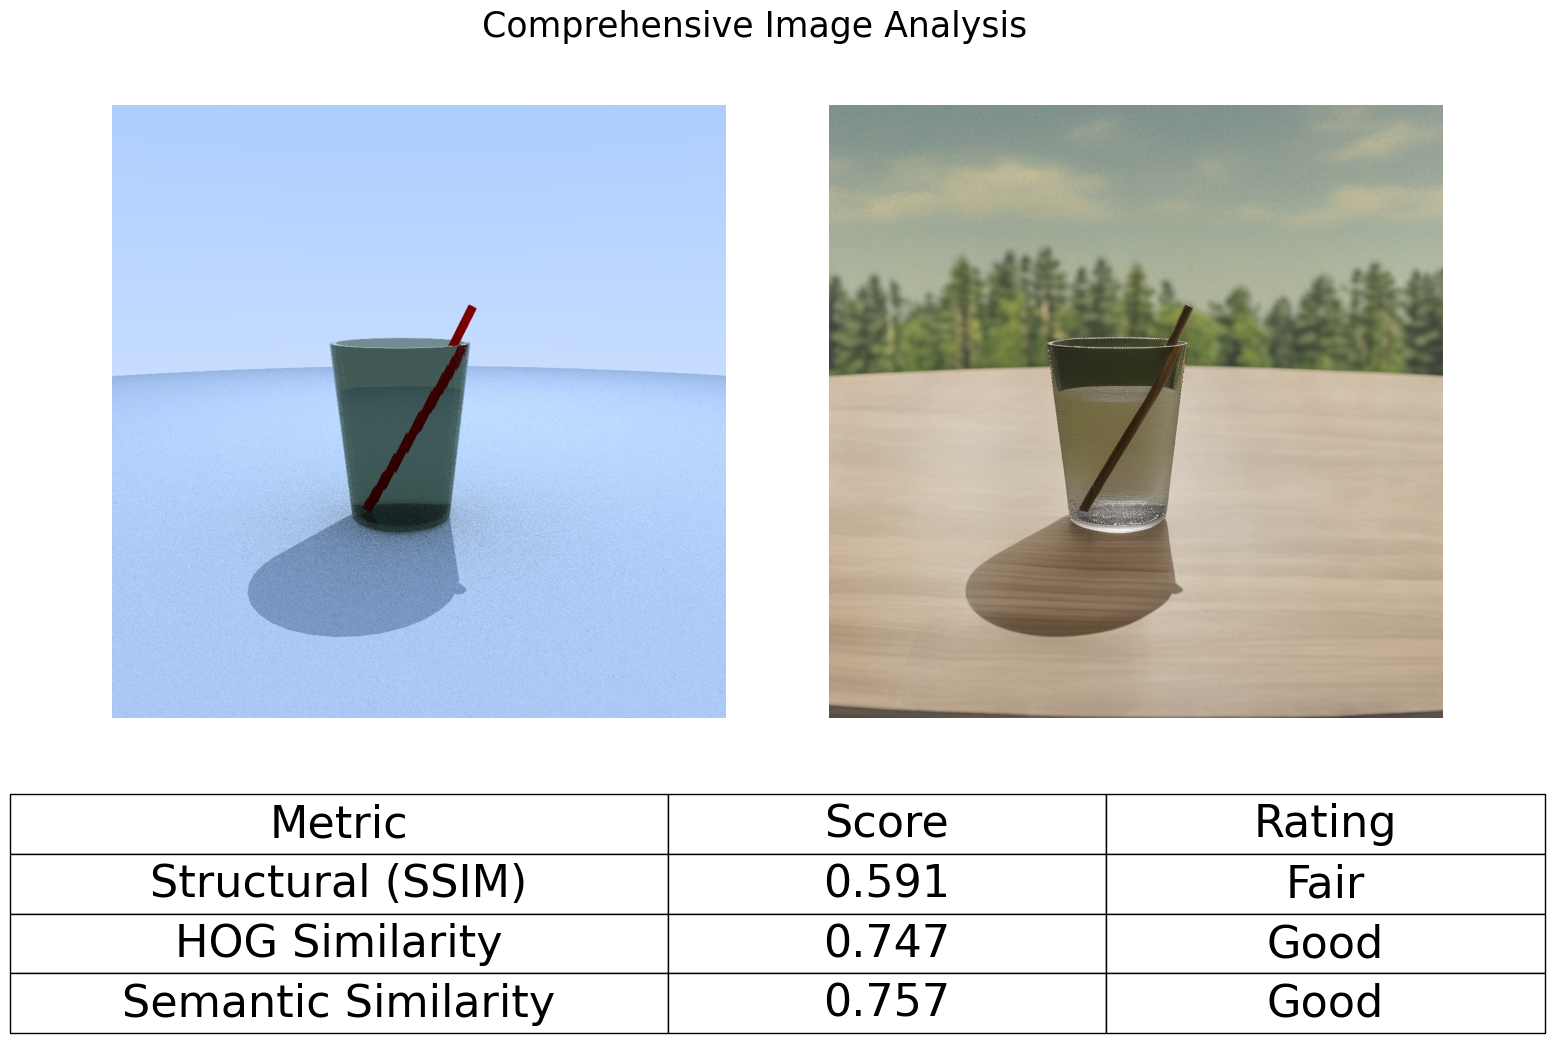

In [23]:
# visualize_analysis("original.png", "enhanced1.png", analyze_image_pair("original.png", "enhanced1.png"))
# visualize_analysis("original.png", "enhanced2.png", analyze_image_pair("original.png", "enhanced2.png"))
# visualize_analysis("original.png", "enhanced3.png", analyze_image_pair("original.png", "enhanced3.png"))